# Task_4 : Customer Segmentation Visualization

In [37]:
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
Data = pd.read_csv(r"C:\Users\Zeeshii_96\Desktop\SaiketSystem_InternOfferLetter\Telco_Customer_Churn_Dataset  (3).csv")
Data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [39]:
#Checking Data Types
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [40]:
#Checking Null Values
Data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [41]:
#Checking the White Spaces
(Data['TotalCharges'] == " ").sum()

np.int64(11)

In [42]:
#Replacing those 11 spaces with Under_scores
Data['TotalCharges'] = Data['TotalCharges'].replace(" ","_")

In [43]:
#Spaces are Cleaned
(Data['TotalCharges'] == " ").sum()

np.int64(0)

In [44]:
Data['TotalCharges'].dtype

dtype('O')

In [45]:
#Conversion to numeric terms
Data["TotalCharges"] = pd.to_numeric(Data["TotalCharges"], errors="coerce")

In [46]:
#Converted
Data['TotalCharges'].dtype

dtype('float64')

In [47]:
#Eliminating Missing Rows
Data = Data.dropna()

In [48]:
Data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [49]:
Data.duplicated().sum() #Hence there are No duplicates ELSE we could do Data = Data.drop_duplicates()

np.int64(0)

In [50]:
#Converts names to lowercase
#Replaces spaces with '_'
Data.columns = Data.columns.str.lower().str.replace(" ","_")

In [51]:
Data["churn"] = Data["churn"].replace({1 : "Yes", 0 : "No"})

In [52]:
Data['churn'].reset_index()

,index,churn
0,0,No
1,1,No
2,2,Yes
3,3,No
4,4,Yes
...,...,...
7027,7038,No
7028,7039,No
7029,7040,No
7030,7041,Yes


In [53]:
churn_counts = Data['churn'].value_counts().reset_index()
churn_counts

,churn,count
0,No,5163
1,Yes,1869


### Visualization of Hist and Box plots

#### Churn Distribution Analysis
Firstly , We analyze how many customers stayed vs left.

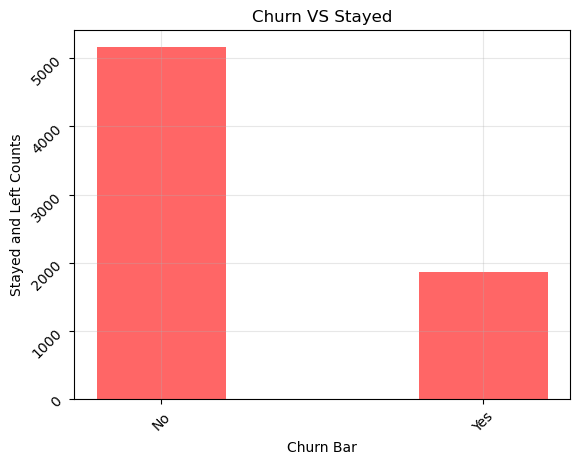

In [54]:

plt.bar(churn_counts["churn"] ,churn_counts["count"] , width = 0.4 ,  color = "red" , alpha = 0.6 , align = "center")
plt.title("Churn VS Stayed")
plt.xlabel("Churn Bar")
plt.ylabel("Stayed and Left Counts")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.grid(alpha=0.3)
plt.show()

## Insight:
The majority of customers have not churned, indicating good customer retention. 
However, a significant portion of customers have left, highlighting the need for 
further analysis to identify factors contributing to churn.

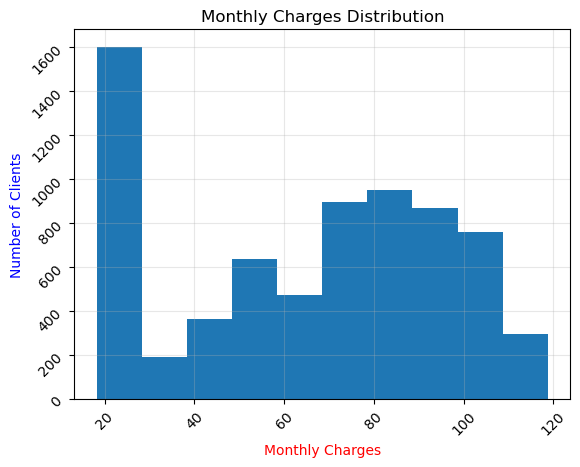

In [55]:
plt.hist(Data["monthlycharges"])
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges", color = 'red')
plt.ylabel("Number of Clients" , color = 'blue')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.grid(alpha=0.3)
plt.show()

## Insight:
The histogram shows the distribution of monthly charges among customers. 
Most customers fall within the medium to high charge range (around 70–100), 
while fewer customers are in the low and very high charge ranges.

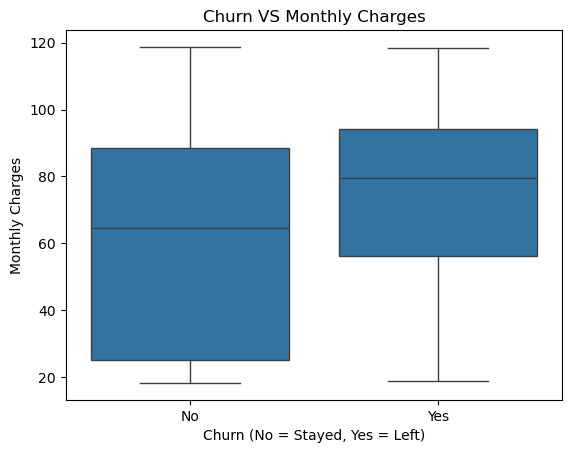

In [56]:
sns.boxplot(x = 'churn' , y = 'monthlycharges' , data = Data)
plt.title("Churn VS Monthly Charges")
plt.xlabel("Churn (No = Stayed, Yes = Left)")
plt.ylabel("Monthly Charges")
plt.show()

## Insight:
The boxplot shows that customers who churn (Yes) have higher monthly charges 
compared to those who stay (No). This indicates that higher-paying customers 
are more likely to leave, possibly due to expensive plans or dissatisfaction 
with pricing.

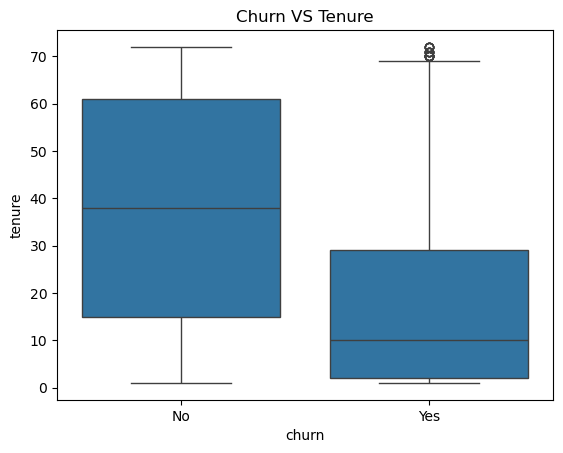

In [57]:
sns.boxplot(x = "churn", y = "tenure", data = Data)
plt.title("Churn VS Tenure")
plt.show()

In [58]:
counts = Data['churn'].value_counts()
percent = Data["churn"].value_counts(normalize = True).mul(100).round(2)

#Converting to Table Format using DataFrame

churn_table = pd.DataFrame({
    "Churn" : counts.index,
    "Count" : counts.values,
    "Percentage": percent.values
})
    
churn_table

,Churn,Count,Percentage
0,No,5163,73.42
1,Yes,1869,26.58


## Insight:
Approximately 27% of customers have churned, while around 73% have stayed. 
The boxplot shows that most churned customers have low tenure (around 0–20 months), 
indicating that new customers are more likely to leave. However, a few long-term 
customers (up to ~70 months) also churn, as seen in the outliers.

In [59]:
Data.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [60]:
#Grouping Clients Based on how long they stayed
Data["tenure_group"] = pd.cut(Data["tenure"], bins = [0,12,36,72], labels = ["0-12", "13-36", "37+"])
Data["tenure_group"]

0        0-12
1       13-36
2        0-12
3         37+
4        0-12
        ...  
7038    13-36
7039      37+
7040     0-12
7041     0-12
7042      37+
Name: tenure_group, Length: 7032, dtype: category
Categories (3, object): ['0-12' < '13-36' < '37+']

In [62]:
tenure_table = Data["tenure_group"].value_counts().reset_index()
tenure_table


,tenure_group,count
0,37+,3001
1,0-12,2175
2,13-36,1856


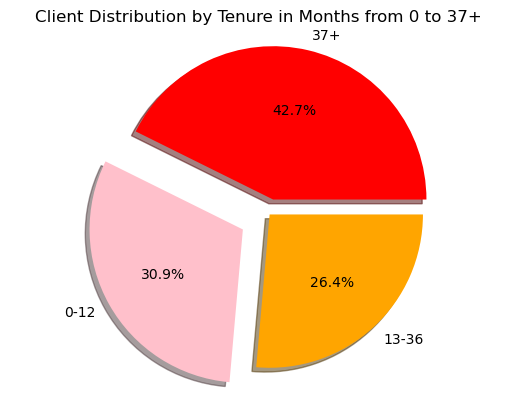

In [63]:
plt.pie(tenure_table["count"] , labels = tenure_table["tenure_group"],  explode = [0.1,0.2,0] ,autopct = '%1.1f%%' , colors = ['red','pink','orange'] , shadow = True )
plt.axis('equal')
plt.title("Client Distribution by Tenure in Months from 0 to 37+")
plt.show()

In [66]:
avg_charges = Data.groupby("tenure_group")["monthlycharges"].mean().reset_index().round(2)
avg_charges

,tenure_group,monthlycharges
0,0-12,56.17
1,13-36,63.25
2,37+,72.01


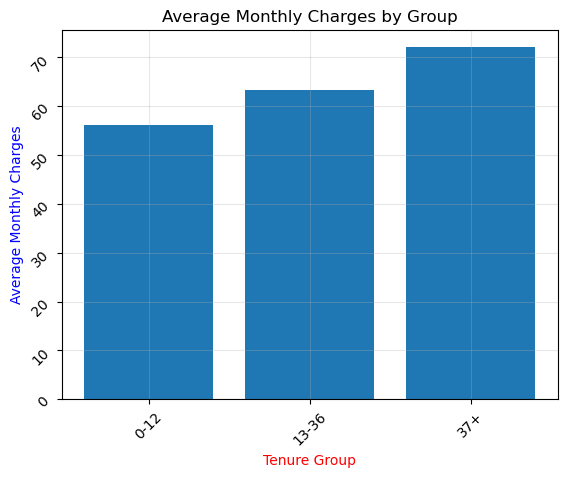

In [71]:
plt.bar(avg_charges["tenure_group"], avg_charges["monthlycharges"])
plt.title("Average Monthly Charges by Group")
plt.xlabel("Tenure Group", color = 'red')
plt.ylabel("Average Monthly Charges" , color = 'blue')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.grid(alpha = 0.3)
plt.show()

## Insight:
The bar chart shows that long-term customers (37+ months) pay higher monthly charges 
compared to new customers (0–12 months). This indicates that loyal customers tend to 
subscribe to more expensive or premium services.